In [1]:
import re
import time
import numpy as np
import pandas as pd
import scipy.optimize
import matplotlib.pyplot as plt
import swmmio
import swmmtoolbox
from pipedream_solver.hydraulics import SuperLink
from pipedream_solver.simulation import Simulation
import pipedream_solver.ngeometry
from pipedream_solver.diagnostics import ErrorTracker, VolumeTracker, ConvergenceTracker

In [2]:
def compute_normal_depth(h, f_A, f_Pe, Q, n, S_o, *args):
    A = f_A(h, *args)
    Pe = f_Pe(h, *args)
    result = Q - np.sqrt(S_o) * A**(5/3) / Pe**(2/3) / n
    return result

def compute_critical_depth(h, f_A, f_B, Q, *args):
    A = f_A(h, *args)
    B = f_B(h, *args)
    g = 9.81
    result = 1 - Q**2 * B / g / A**3
    return result

def normal_depth(f_A, f_Pe, Q, n, S_o, *args, min_depth=1e-3, max_depth=100.):
    try:
        result = scipy.optimize.root_scalar(compute_normal_depth, method='bisect',
                                            bracket=[min_depth, max_depth],
                                            args=(f_A, f_Pe, Q, n,
                                                S_o, *args))
        h = result.root
    except ValueError:
        h = min_depth
    return h
    
def critical_depth(f_A, f_B, Q, *args, min_depth=1e-3, max_depth=100.):
    try:
        result = scipy.optimize.root_scalar(compute_critical_depth, method='bisect',
                                            bracket=[min_depth, max_depth],
                                            args=(f_A, f_B, Q, *args))
        h = result.root
    except ValueError:
        h = min_depth
    return h

In [3]:
swmm = swmmio.Model('../data/extran1/extran1.inp')

links = swmm.links()
weirs = swmm.weirs()
nodes = swmm.nodes()
orifices = swmm.orifices()
subcatchments = swmm.subcatchments()
pumps = swmm.pumps()

In [4]:
superjunctions = nodes.reset_index()
assert swmm.inp.options.loc['FLOW_UNITS', 'Value'] == 'CFS'
superjunctions = superjunctions.rename(columns={'Name' : 'name', 'InvertElev' : 'z_inv',
                                                'MaxDepth' : 'max_depth', 'InitDepth' : 'h_0'})
superjunctions['map_x'] = superjunctions['coords'].str[0].str[0]
superjunctions['map_y'] = superjunctions['coords'].str[0].str[1]
superjunctions['bc'] = ~superjunctions['OutfallType'].isnull()
superjunctions = superjunctions.drop(['SurchargeDepth', 'PondedArea', 'OutfallType', 'StageOrTimeseries', 'coords'], axis=1)
superjunctions['storage'] = 'functional'
superjunctions['a'] = 0.
superjunctions['b'] = 0.
superjunctions['c'] = 1.16
superjunctions['id'] = superjunctions.index
superjunctions['z_inv'] *= 0.3048
superjunctions['h_0'] *= 0.3048
superjunctions['max_depth'] *= 0.3048
superjunctions['max_depth'] = superjunctions['max_depth'].replace(np.nan, np.inf)
superjunctions['h_0'] = superjunctions['h_0'].replace(np.nan, 0.)

In [5]:
superlinks = links.reset_index()
assert (superlinks['Barrels'] == 1).all()
node_map = superjunctions.set_index('name')['id']
superlinks['InletNode'] = superlinks['InletNode'].map(node_map)
superlinks['OutletNode'] = superlinks['OutletNode'].map(node_map)
superlinks['Shape'] = superlinks['Shape'].str.lower()
superlinks['Length'] *= 0.3048
superlinks['Geom1'] *= 0.3048
superlinks['Geom2'] *= 0.3048
superlinks['InOffset'] *= 0.3048
superlinks['OutOffset'] *= 0.3048
superlinks['InitFlow'] *= 0.028316832
superlinks = superlinks.rename(columns={'InletNode' : 'sj_0', 'OutletNode' : 'sj_1',
                                        'Name' : 'name', 'Length' : 'dx',
                                        'Roughness' : 'roughness', 'Shape' : 'shape',
                                        'Geom1' : 'g1', 'Geom2' : 'g2', 'Geom3' : 'g3',
                                        'Geom4' : 'g4', 'InOffset' : 'in_offset', 
                                        'OutOffset' : 'out_offset', 'InitFlow' : 'Q_0'})
superlinks = superlinks.drop(['MaxFlow', 'Barrels', 'coords'], axis=1)
superlinks['A_s'] = 1e-3
superlinks['A_c'] = 0.
superlinks['C'] = 0.
superlinks['ctrl'] = False
superlinks['C_uk'] = 0.
superlinks['C_dk'] = 0.
superlinks['h_0'] = 1e-3
superlinks['dx_uk'] = 0.
superlinks['dx_dk'] = 0.
superlinks['g2'] = 1e-3

In [6]:
weirs = {
    'name' : [f'w{i}' for i in range(0, 9)],
    'id' : [0, 1, 2, 3, 4, 5, 6, 7, 8],
    'sj_0' : [0, 1, 2, 3, 4, 5, 6, 7, 8],
    'sj_1' : [9, 9, 9, 9, 9, 9, 9, 9, 9],
    'z_w' : superjunctions.loc[[0, 1, 2, 3, 4, 5, 6, 7, 8], 'max_depth'],
    'y_max': 9 * [10.],
    'Cr' : 9 * [1.84],
    'Ct' : 9 * [0.],
    'L' : np.sqrt(4 * superjunctions.loc[[0, 1, 2, 3, 4, 5, 6, 7, 8], 'c'] / np.pi) * np.pi, 
    's' : 0.
}

weirs = pd.DataFrame.from_dict(weirs)

In [7]:
model = SuperLink(superlinks, superjunctions, weirs=weirs, internal_links=4)

In [8]:
total_inflow = swmmtoolbox.extract('../data/extran1/extran1.out', 'node,,Lateral_inflow')
node_heads = swmmtoolbox.extract('../data/extran1/extran1.out', 'node,,Hydraulic_head')
link_flows = swmmtoolbox.extract('../data/extran1/extran1.out', 'link,,Flow_rate')

total_inflow.columns = total_inflow.columns.str.extract('node_(.*)_Lateral_inflow')
total_inflow.columns = total_inflow.columns.str[0]
total_inflow = total_inflow[model.superjunctions['name'].values]

node_heads.columns = node_heads.columns.str.extract('node_(.*)_Hydraulic_head')
node_heads.columns = node_heads.columns.str[0]
node_heads = node_heads[model.superjunctions['name'].values]

link_flows.columns = link_flows.columns.str.extract('link_(.*)_Flow_rate')
link_flows.columns = link_flows.columns.str[0]
link_flows = link_flows[model.superlinks['name'].values]

In [9]:
start_time = pd.to_datetime(swmm.inp.options.loc['START_DATE'] + ' ' + swmm.inp.options.loc['START_TIME'])['Value']

Q_in = 0.028316832 * total_inflow.copy()
Q_in.fillna(0., inplace=True)
Q_in.loc[start_time] = 0.
Q_in.sort_index(inplace=True)
Q_in.index = 1e-9 * (Q_in.index - start_time).astype(int)

In [10]:
# Variables needed to compute critical/normal depth
k = np.flatnonzero(np.isin(model._J_dk, np.flatnonzero(model.bc))).item()
sel = model._ki == k
S_o = model._S_o_ik[sel].mean()
n = model._n_ik[sel].mean()
g1 = model._g1_ik[sel].mean()
g2 = model._g2_ik[sel].mean()
g3 = model._g3_ik[sel].mean()

In [11]:
error_tracker = ErrorTracker(model, rtol=1)
volume_tracker = VolumeTracker(model)
model.bind_callback(error_tracker, 'error_tracker')
model.bind_callback(volume_tracker, 'volume_tracker')

In [12]:
continuity_errors_j = {}
continuity_errors_Ik = {}
momentum_errors_ik = {}
momentum_errors_uk = {}
momentum_errors_dk = {}
continuity_magnitudes_j = {}
continuity_magnitudes_Ik = {}
momentum_magnitudes_ik = {}
momentum_magnitudes_uk = {}
momentum_magnitudes_dk = {}
volumes_j = {}
volumes_ik = {}
volumes_Ik = {}
volumes_uk = {}
volumes_dk = {}
volume_fluxes_j = {}
volume_fluxes_Ik = {}
dts = {}

In [13]:
max_dt = pd.to_timedelta(swmm.inp.options.loc['ROUTING_STEP', 'Value']).seconds
min_dt = float(swmm.inp.options.loc['MINIMUM_STEP', 'Value'])
max_iter = 10

Q_Ik = 0. * pd.DataFrame(np.ones((Q_in.shape[0], model._I.size)), index=Q_in.index)
u_w = np.ones(weirs.shape[0], dtype=np.float64)

In [14]:
with Simulation(model, Q_in=Q_in, Q_Ik=Q_Ik, t_start=0, t_end=8*3600) as simulation:
    # While simulation time has not expired...
    while simulation.t <= simulation.t_end:
        Q_bc = model._Q_ik[sel].mean()
        h_n = normal_depth(pipedream_solver.ngeometry.Trapezoidal_A_ik,
                           pipedream_solver.ngeometry.Trapezoidal_Pe_ik, Q_bc, n, S_o, g1, g2, g3)
        h_c = critical_depth(pipedream_solver.ngeometry.Trapezoidal_A_ik,
                             pipedream_solver.ngeometry.Trapezoidal_B_ik, Q_bc, g1, g2, g3)
        h_bc = min(h_n, h_c)
        H_bc = np.where(model.bc, model._z_inv_j + h_bc, 0.)
        # Step model forward in time
        dt = max_dt
        simulation.step(dt=dt, H_bc=H_bc, u_w=u_w, num_iter=max_iter)
        while simulation.model.iter_elapsed == max_iter:
            model.load_state()
            dt = max(min_dt, dt / 2)
            simulation.step(dt=dt, H_bc=H_bc, u_w=u_w, num_iter=max_iter)
            if dt == min_dt:
                print(f'Did not converge at t={model.t}')
                break
        # Record internal depth and flow states
        simulation.record_state()
        # Print progress bar
        simulation.print_progress()

        # Track errors
        dts[simulation.t] = dt
        continuity_error_j = error_tracker.continuity_error_j.copy()
        continuity_error_Ik = error_tracker.continuity_error_Ik.copy()
        momentum_error_ik = error_tracker.momentum_error_ik.copy()
        momentum_error_uk = error_tracker.momentum_error_uk.copy()
        momentum_error_dk = error_tracker.momentum_error_dk.copy()
        continuity_errors_j[simulation.t] = (continuity_error_j)
        continuity_errors_Ik[simulation.t] = (continuity_error_Ik)
        momentum_errors_ik[simulation.t] = (momentum_error_ik)
        momentum_errors_uk[simulation.t] = (momentum_error_uk)
        momentum_errors_dk[simulation.t] = (momentum_error_dk)
        continuity_magnitude_j = error_tracker.continuity_magnitude_j.copy()
        continuity_magnitude_Ik = error_tracker.continuity_magnitude_Ik.copy()
        momentum_magnitude_ik = error_tracker.momentum_magnitude_ik.copy()
        momentum_magnitude_uk = error_tracker.momentum_magnitude_uk.copy()
        momentum_magnitude_dk = error_tracker.momentum_magnitude_dk.copy()
        continuity_magnitudes_j[simulation.t] = (continuity_magnitude_j)
        continuity_magnitudes_Ik[simulation.t] = (continuity_magnitude_Ik)
        momentum_magnitudes_ik[simulation.t] = (momentum_magnitude_ik)
        momentum_magnitudes_uk[simulation.t] = (momentum_magnitude_uk)
        momentum_magnitudes_dk[simulation.t] = (momentum_magnitude_dk)
        # Track volumes
        volume_j = volume_tracker.volume_j.copy()
        volume_Ik = volume_tracker.volume_Ik.copy()
        volume_ik = volume_tracker.volume_ik.copy()
        volume_uk = volume_tracker.volume_uk.copy()
        volume_dk = volume_tracker.volume_dk.copy()
        volume_flux_j = volume_tracker.volume_flux_j.copy()
        volume_flux_Ik = volume_tracker.volume_flux_Ik.copy()
        volumes_j[simulation.t] = (volume_j)
        volumes_Ik[simulation.t] = (volume_Ik)
        volumes_ik[simulation.t] = (volume_ik)
        volumes_uk[simulation.t] = (volume_uk)
        volumes_dk[simulation.t] = (volume_dk)
        volume_fluxes_j[simulation.t] = (volume_flux_j)
        volume_fluxes_Ik[simulation.t] = (volume_flux_Ik)

[==================================================] 100.0% [1.59 s]

<Axes: >

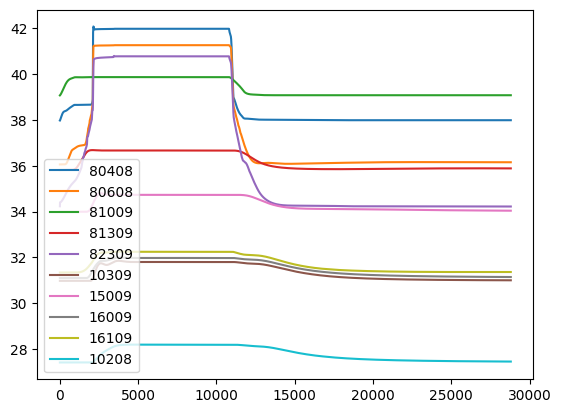

In [15]:
simulation.states.H_j.plot()

In [16]:
H_j = simulation.states.H_j.copy()
H_j.index = pd.to_timedelta(H_j.index, unit='s') + start_time

In [17]:
Q_ik = simulation.states.Q_ik.copy()
Q_ik.index = pd.to_timedelta(Q_ik.index, unit='s') + start_time

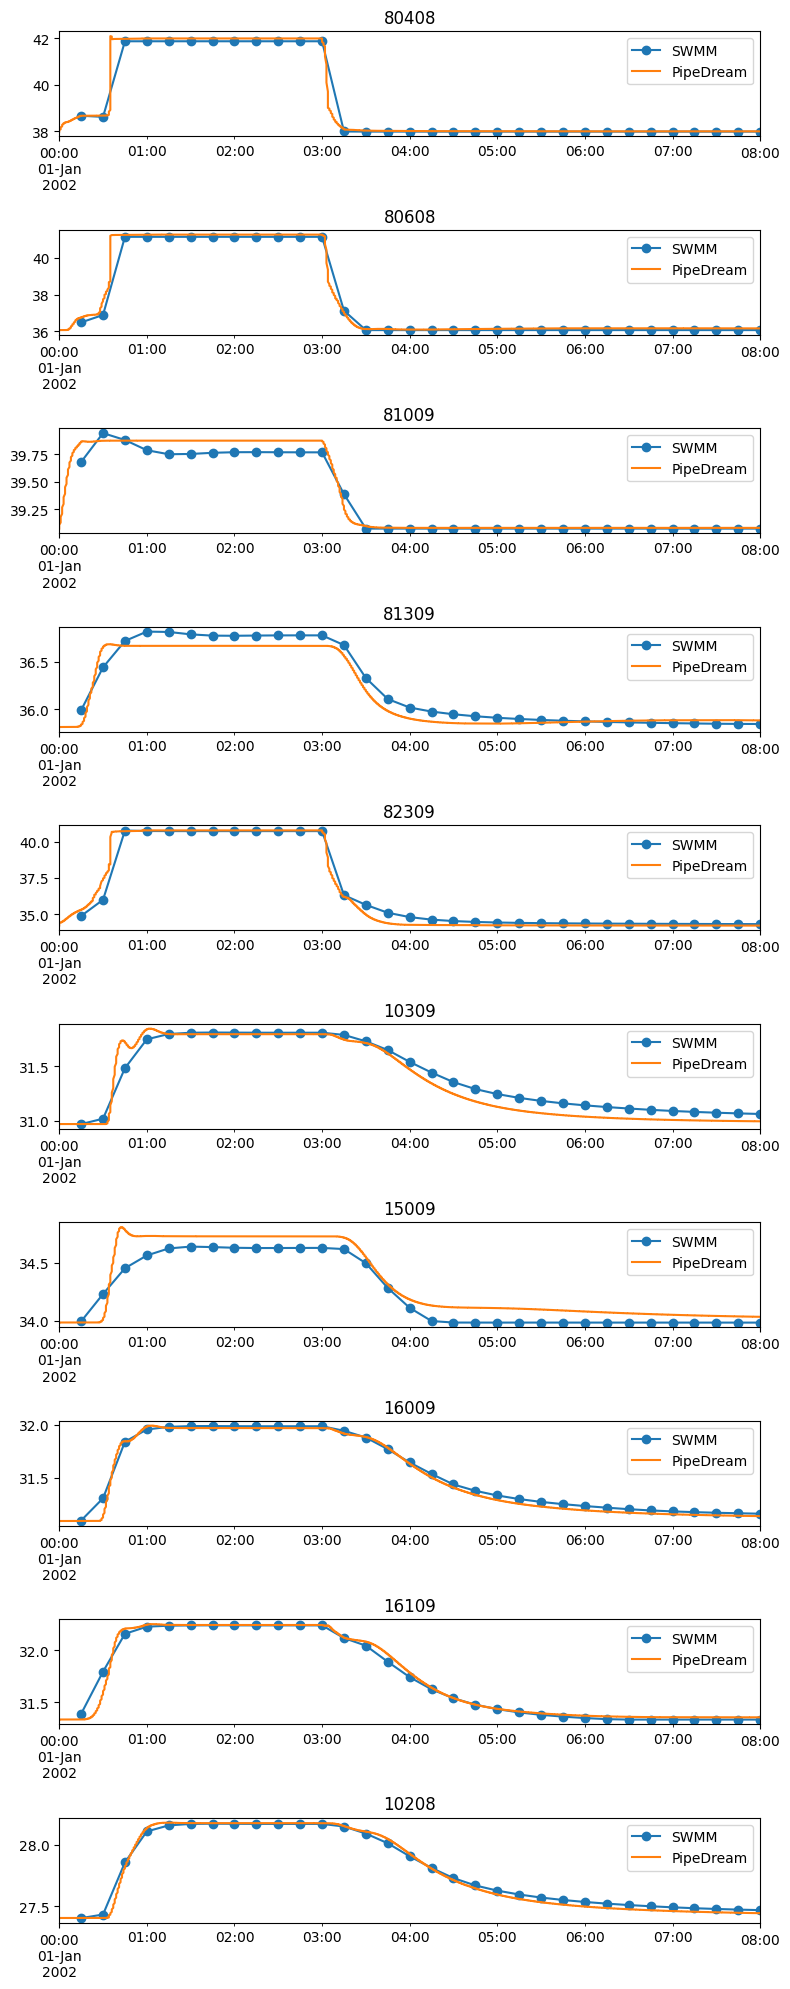

In [18]:
fig, ax = plt.subplots(len(node_heads.columns), figsize=(8, 20))
for i, index in enumerate(node_heads.columns):
    (0.3048 * node_heads[index]).plot(ax=ax[i], label='SWMM', marker='o')
    (H_j[index]).plot(ax=ax[i], label='PipeDream')
    j = model.superjunctions.set_index('name').loc[index, 'id']
    #max_depth = model.max_depth[j]
    #if np.isfinite(max_depth):
    #    ax[i].axhline(max_depth + model._z_inv_j[j], linestyle='--', c='k')
    ax[i].set_title(index)
    ax[i].legend()
plt.tight_layout()

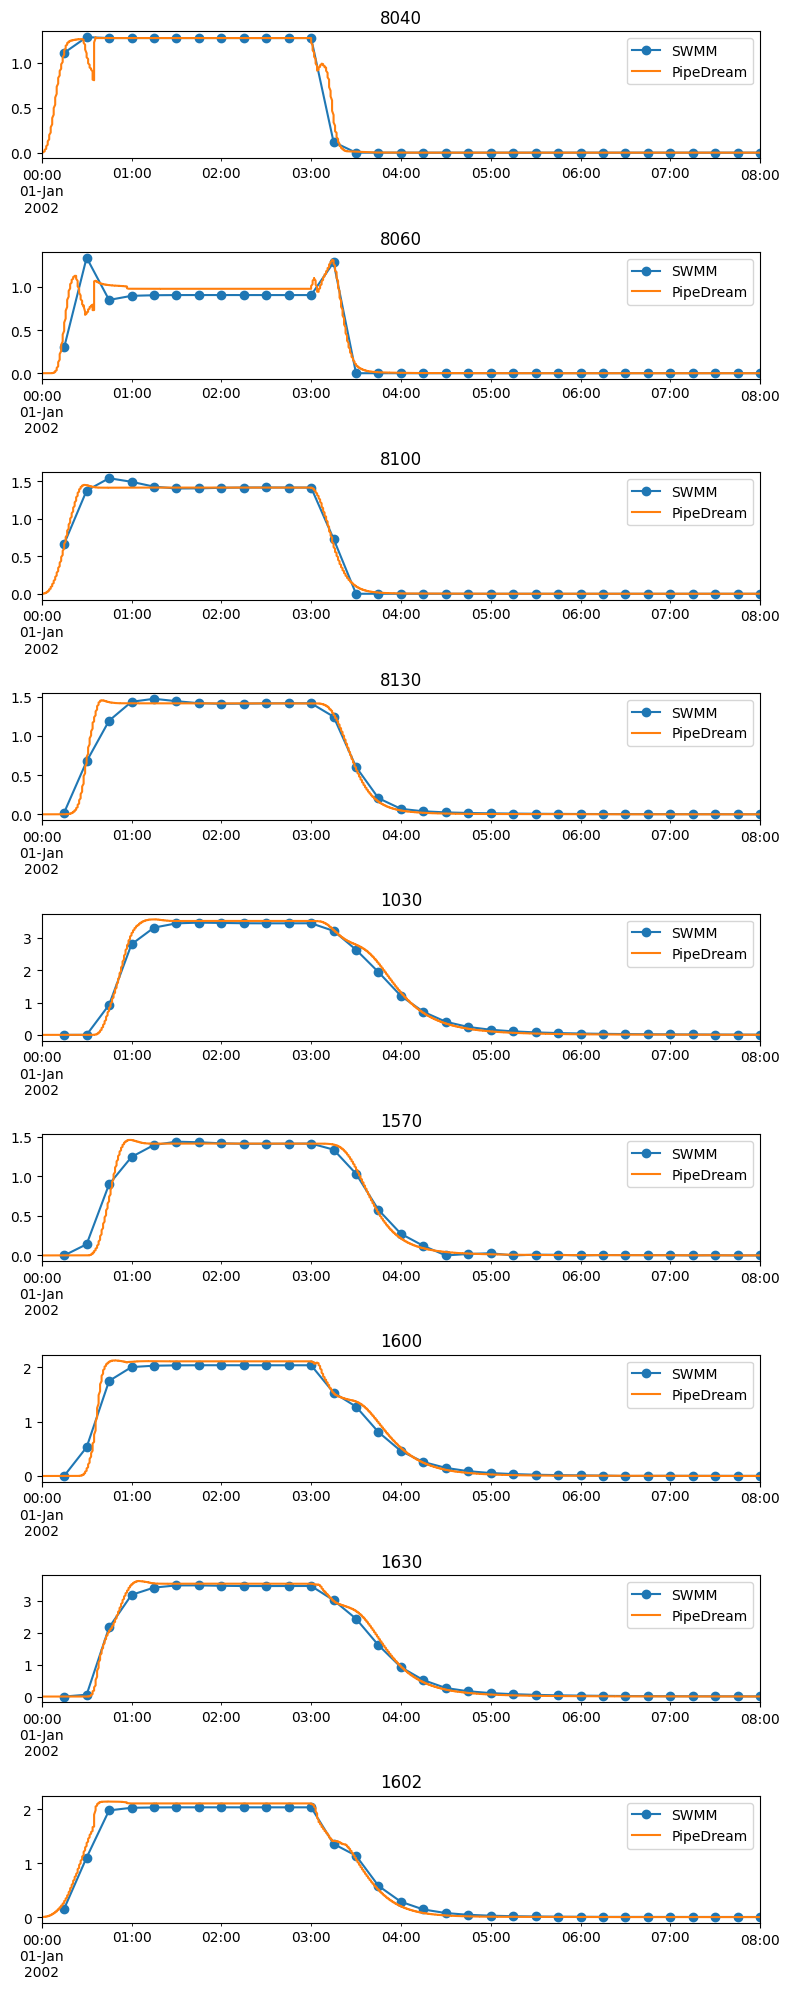

In [19]:
fig, ax = plt.subplots(len(link_flows.columns), figsize=(8, 20))
for i, index in enumerate(link_flows.columns):
    junctions = np.flatnonzero(model._ki == model.superlinks.reset_index().set_index('name').loc[index, 'index'])
    (0.028316832 * link_flows[index]).plot(ax=ax[i], label='SWMM', marker='o')
    Q_ik[junctions].mean(axis=1).plot(ax=ax[i], label='PipeDream')
    ax[i].set_title(index)
    ax[i].legend()
plt.tight_layout()

In [20]:
continuity_errors_j = pd.DataFrame.from_dict(continuity_errors_j, orient='index')
continuity_errors_Ik = pd.DataFrame.from_dict(continuity_errors_Ik, orient='index')
momentum_errors_ik = pd.DataFrame.from_dict(momentum_errors_ik, orient='index')
momentum_errors_uk = pd.DataFrame.from_dict(momentum_errors_uk, orient='index')
momentum_errors_dk = pd.DataFrame.from_dict(momentum_errors_dk, orient='index')
continuity_magnitudes_j = pd.DataFrame.from_dict(continuity_magnitudes_j, orient='index')
continuity_magnitudes_Ik = pd.DataFrame.from_dict(continuity_magnitudes_Ik, orient='index')
momentum_magnitudes_ik = pd.DataFrame.from_dict(momentum_magnitudes_ik, orient='index')
momentum_magnitudes_uk = pd.DataFrame.from_dict(momentum_magnitudes_uk, orient='index')
momentum_magnitudes_dk = pd.DataFrame.from_dict(momentum_magnitudes_dk, orient='index')

volumes_j = pd.DataFrame.from_dict(volumes_j, orient='index')
volumes_Ik = pd.DataFrame.from_dict(volumes_Ik, orient='index')
volumes_ik = pd.DataFrame.from_dict(volumes_ik, orient='index')
volumes_uk = pd.DataFrame.from_dict(volumes_uk, orient='index')
volumes_dk = pd.DataFrame.from_dict(volumes_dk, orient='index')

volume_fluxes_j = pd.DataFrame.from_dict(volume_fluxes_j, orient='index')
volume_fluxes_Ik = pd.DataFrame.from_dict(volume_fluxes_Ik, orient='index')

<Axes: >

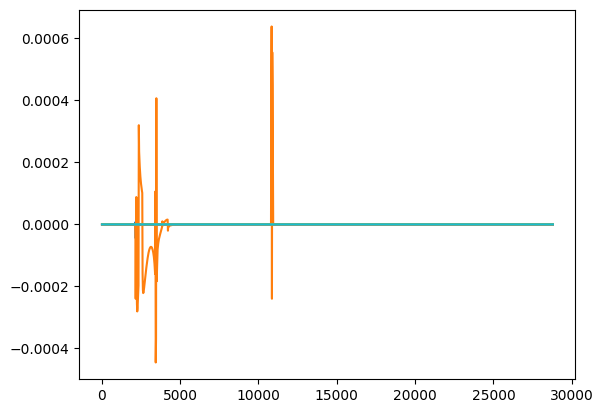

In [21]:
(continuity_errors_j / continuity_magnitudes_j).plot(legend=False)

<Axes: >

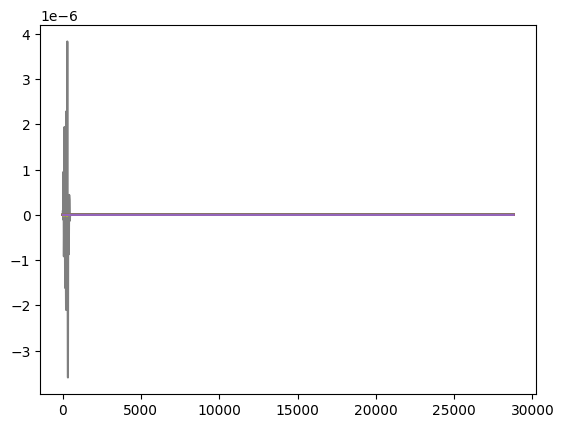

In [22]:
(continuity_errors_Ik).plot(legend=False)

<Axes: >

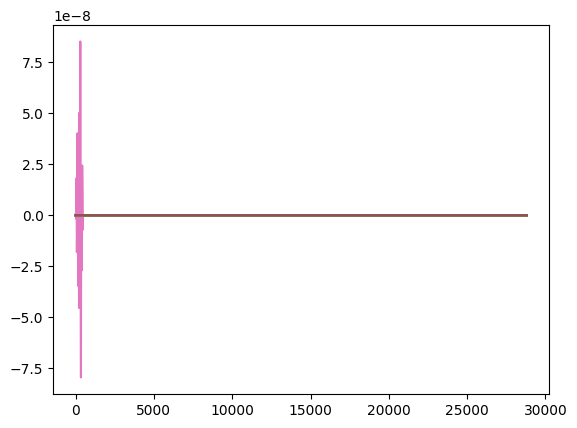

In [23]:
(momentum_errors_ik).plot(legend=False)

<Axes: >

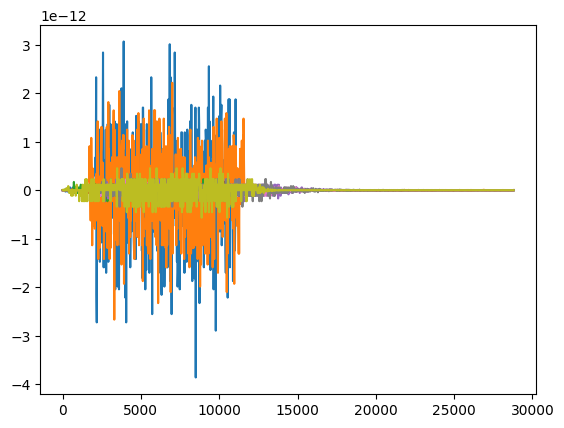

In [24]:
(momentum_errors_uk).plot(legend=False)

<Axes: >

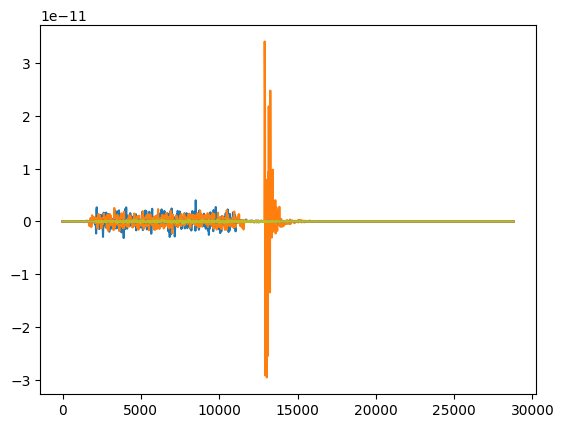

In [25]:
(momentum_errors_dk).plot(legend=False)

In [26]:
Q_w_out = (simulation.states.Q_w.sum(axis=1) * simulation.states.Q_w.index.diff()).fillna(0.)

total_vol = (volumes_j.sum(axis=1) + volumes_Ik.sum(axis=1)
            + volumes_ik.sum(axis=1) + volumes_uk.sum(axis=1) + volumes_dk.sum(axis=1))
total_vol_flux = (volume_fluxes_j.sum(axis=1) + volume_fluxes_Ik.sum(axis=1) - Q_w_out).cumsum(axis=0)

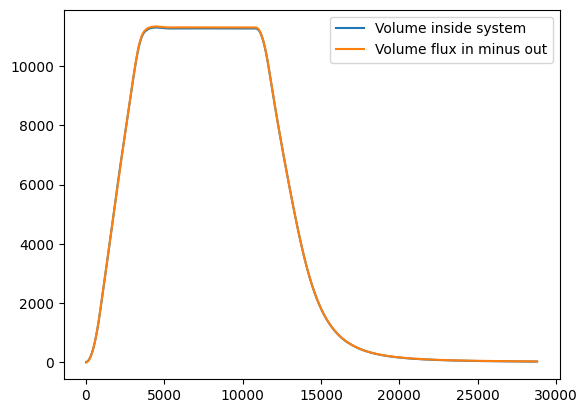

In [27]:
total_vol.plot(label='Volume inside system')
total_vol_flux.plot(label='Volume flux in minus out')
plt.legend()